In [1]:
import numpy as np
import tensorflow as tf
import re  #for removing english characters and numbers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd

# Specify the file path to your Excel file
file_path = '/content/drive/MyDrive/FYP/Dataset20k.xlsx'

# Load the Excel file into a DataFrame
df = pd.read_excel(file_path, sheet_name='Sheet1', usecols=['Dzongkha'])

# Extract the text data from a specific column (e.g., 'column_name')
text = df.to_string(index=False)


In [4]:
#Removing the # from the data set
text = text.replace('#', '')
text = text.replace('?', '')
text = text.replace('།', '')
text = re.sub(r'[a-zA-Z0-9]', '', text)

In [5]:
#Removing the dzongkha period after the word
text = text.replace(' ','$')
text = text.replace('་$', '$་')
text = text.replace('$$','')
text = text.replace('$',' ')
text = text.replace('་ ','')
text = text.replace(' ་',' ')

In [6]:
#Now the Tokinization
tokenizer = Tokenizer()#oov_token=<'oov'>
tokenizer.fit_on_texts([text])
total_words = len(tokenizer.word_index) + 1

In [7]:
#Now forming the N-grams from the sequences
input_sequences = []
for line in text.split('\n'):  #we're splitting it into individual lines
  token_list = tokenizer.texts_to_sequences([line])[0]
  for i in range(1, len(token_list)):
    n_gram_sequence = token_list[:i+1]
    input_sequences.append(n_gram_sequence)

In [8]:
#input sequences are padded to have same length
max_sequence_len = max([len(seq) for seq in input_sequences])
input_sequences = np.array(pad_sequences(input_sequences, maxlen=max_sequence_len, padding='pre'))

In [9]:
max_sequence_len

22

In [10]:
#split into input and output
#X will contain all the N-grams, except for the last token in each N-gram.
X = input_sequences[:, :-1]
#y will contain the last token in each N-gram, which is typically used as the target
#or output for a sequence prediction task.
y = input_sequences[:, -1]

In [11]:
#output is converted to one-hot encode vectors
y = np.array(tf.keras.utils.to_categorical(y, num_classes=total_words))

In [12]:
#building a neural network architecture to train the model
#This line initialises a sequential neural network model.
model = Sequential()
#Embedding layer
# integer sequences (like the tokenized text) into fixed-sized dense vectors.
model.add(Embedding(total_words, 100, input_length=max_sequence_len-1))
model.add(LSTM(256))
#converts the network's output into a probability distribution over the vocabulary
model.add(Dense(total_words, activation='softmax'))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 21, 100)           759300    
                                                                 
 lstm (LSTM)                 (None, 256)               365568    
                                                                 
 dense (Dense)               (None, 7593)              1951401   
                                                                 
Total params: 3076269 (11.74 MB)
Trainable params: 3076269 (11.74 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________
None


In [13]:
#training the model
model.compile(loss='categorical_crossentropy' , optimizer='adam', metrics=['accuracy'])
#Categorical_crossentropy is a loss function that the model will use during training
# Train the model in batches
batch_size = 64  # You can adjust the batch size as needed
epochs = 200
history = model.fit(X, y, epochs=epochs, batch_size=batch_size, validation_split=0.2, verbose=1)

Epoch 1/200
1446/1446 [==============================] - 38s 23ms/step - loss: 5.7103 - accuracy: 0.1016 - val_loss: 5.3132 - val_accuracy: 0.1330
Epoch 2/200
1446/1446 [==============================] - 22s 15ms/step - loss: 4.8917 - accuracy: 0.1836 - val_loss: 5.0508 - val_accuracy: 0.1844
Epoch 3/200
1446/1446 [==============================] - 19s 13ms/step - loss: 4.4609 - accuracy: 0.2292 - val_loss: 4.9311 - val_accuracy: 0.2158
Epoch 4/200
1446/1446 [==============================] - 22s 15ms/step - loss: 4.1415 - accuracy: 0.2573 - val_loss: 4.9601 - val_accuracy: 0.2219
Epoch 5/200
1446/1446 [==============================] - 19s 13ms/step - loss: 3.8738 - accuracy: 0.2785 - val_loss: 5.0128 - val_accuracy: 0.2226
Epoch 6/200
1446/1446 [==============================] - 19s 13ms/step - loss: 3.6379 - accuracy: 0.2999 - val_loss: 5.0792 - val_accuracy: 0.2295
Epoch 7/200
1446/1446 [==============================] - 19s 13ms/step - loss: 3.4246 - accuracy: 0.3191 - val_loss: 5

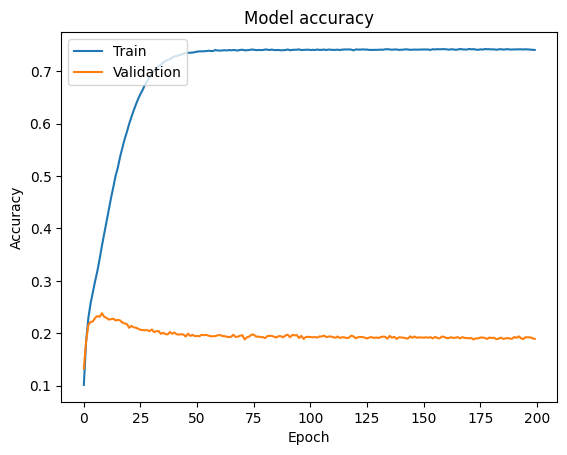

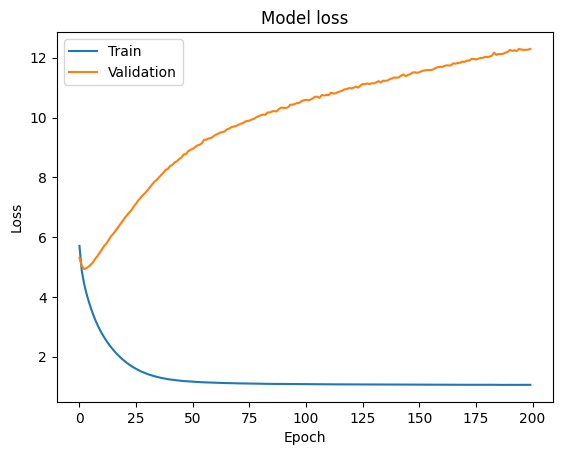

In [14]:
# Plot training & validation accuracy values
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [15]:
seed_text = input("Input the seed text: ")
next_words = 1

for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]

    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted_probs = model.predict(token_list)

    # Get the top N predictions
    top_n = 5  # You can adjust the number of top predictions as needed
    top_indices = predicted_probs[0].argsort()[-top_n:][::-1]

    # Create a list of words corresponding to the top indices
    top_words = [word for word, index in tokenizer.word_index.items() if index in top_indices]

    # Output the top predicted words
    print("Top Predicted Words:", top_words)




Input the seed text: h
1/1 [==============================] - 0s 427ms/step
Top Predicted Words: ['ང', 'ང་བཅས', 'དེ', 'ཟེར', 'ཟེརཝ']


In [16]:
#save the model
model.save('model_LSTM_PRE.h5')

/usr/local/lib/python3.10/dist-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
